# 한글 지문자 31종 MobileNetV2 학습

기존 `EX_06_RPS_MobileNetV2_Augmentation.ipynb`의 흐름을 바탕으로 수정한 버전입니다.

- 데이터 폴더에서 클래스 이름 자동 인식
- 클래스별 `train 70% / validation 20% / test 10%` 자동 분할
- MobileNetV2 전이학습
- 최고 validation 성능 모델 저장
- test 데이터로 최종 성능 평가
- 클래스 이름 JSON 저장
- ONNX 변환 및 다운로드

데이터셋은 아래처럼 **클래스 폴더만 한 번 정리**하면 됩니다.

```text
dataset/
├── ㄱ/
│   ├── image_0000.png
│   └── ...
├── ㄴ/
├── ㄷ/
├── ...
└── ㅢ/
```


## 1. 라이브러리 불러오기

In [1]:
import os
import json
import glob
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

print("NumPy Version      :", np.__version__)
print("TensorFlow Version :", tf.__version__)
print("OpenCV Version     :", cv2.__version__)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


NumPy Version      : 2.0.2
TensorFlow Version : 2.20.0
OpenCV Version     : 4.13.0


## 1-1. Colab 한글 폰트 설정

예측 결과와 Confusion Matrix에서 `ㄱ`, `ㄴ`, `ㅏ` 등이 네모로 깨지지 않도록
나눔고딕 폰트를 설치하고 적용합니다.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
적용된 한글 폰트: NanumGothic


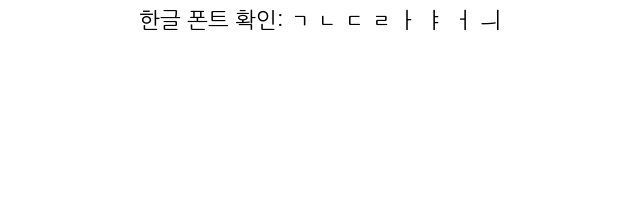

In [2]:
# Colab 한글 폰트 설치
!apt-get -qq update
!apt-get -qq install -y fonts-nanum > /dev/null

import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

if not os.path.exists(font_path):
    raise FileNotFoundError(
        f"한글 폰트를 찾지 못했습니다: {font_path}"
    )

# Matplotlib에 폰트 파일 직접 등록
fm.fontManager.addfont(font_path)

# 파일 경로를 이용해 폰트 객체 생성
korean_font = fm.FontProperties(
    fname=font_path
)

font_name = korean_font.get_name()

# 기존에 잘못 등록된 전역 폰트 설정 초기화
mpl.rcParams.update(
    mpl.rcParamsDefault
)

# 한글 그래프에서 마이너스 기호 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False

print("적용된 한글 폰트:", font_name)

# 한글 출력 확인
fig, ax = plt.subplots(
    figsize=(8, 2)
)

ax.set_title(
    "한글 폰트 확인: ㄱ ㄴ ㄷ ㄹ ㅏ ㅑ ㅓ ㅢ",
    fontproperties=korean_font,
    fontsize=16
)

ax.axis("off")
plt.show()

## 2. Google Drive 연결

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted.')
    COLAB = True
except Exception as e:
    print('Local environment:', e)
    COLAB = False


Mounted at /content/drive
Google Drive mounted.


## 3. 데이터셋 ZIP 압축 해제 및 경로 설정

아래 `DATASET_ZIP` 경로를 실제 ZIP 파일 위치에 맞게 수정하세요.

ZIP 내부 또는 압축 해제 후 폴더 구조는 다음 중 하나면 됩니다.

```text
dataset.zip
└── dataset/
    ├── ㄱ/
    ├── ㄴ/
    └── ...
```

또는 ZIP 최상위에 바로 클래스 폴더가 있어도 됩니다.


In [4]:
# ===== 사용자가 수정할 부분 =====
DATASET_ZIP = "/content/drive/MyDrive/ai/files/DataSet.zip"
EXTRACT_ROOT = "/content/korean_fingerspelling_data"
# ================================

if COLAB:
    !rm -rf "$EXTRACT_ROOT"
    !mkdir -p "$EXTRACT_ROOT"
    !unzip -q -o "$DATASET_ZIP" -d "$EXTRACT_ROOT"

print("압축 해제 위치:", EXTRACT_ROOT)


압축 해제 위치: /content/korean_fingerspelling_data


## 4. 실제 클래스 폴더 자동 탐색

In [5]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

KOREAN_CLASS_NAMES = [
    "ㄱ", "ㄴ", "ㄷ", "ㄹ", "ㅁ", "ㅂ", "ㅅ",
    "ㅇ", "ㅈ", "ㅊ", "ㅋ", "ㅌ", "ㅍ", "ㅎ",
    "ㅏ", "ㅑ", "ㅓ", "ㅕ", "ㅗ", "ㅛ", "ㅜ",
    "ㅠ", "ㅡ", "ㅣ", "ㅐ", "ㅒ", "ㅔ", "ㅖ",
    "ㅚ", "ㅟ", "ㅢ"
]

def contains_images(folder):
    folder = Path(folder)

    return any(
        p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        for p in folder.rglob("*")
    )

def find_dataset_root(extract_root):
    extract_root = Path(extract_root)

    direct_class_dirs = [
        p for p in extract_root.iterdir()
        if p.is_dir() and contains_images(p)
    ]

    if len(direct_class_dirs) >= 2:
        return extract_root

    candidates = []

    for folder in extract_root.rglob("*"):
        if not folder.is_dir():
            continue

        child_dirs = [
            p for p in folder.iterdir()
            if p.is_dir() and contains_images(p)
        ]

        if len(child_dirs) >= 2:
            candidates.append((len(child_dirs), folder))

    if not candidates:
        raise FileNotFoundError(
            "클래스 폴더를 찾지 못했습니다. "
            "dataset/ㄱ/*.png 형태인지 확인하세요."
        )

    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates[0][1]

def class_sort_key(path):
    if path.name.isdigit():
        return (0, int(path.name))

    if path.name in KOREAN_CLASS_NAMES:
        return (1, KOREAN_CLASS_NAMES.index(path.name))

    return (2, path.name)

DATASET_ROOT = find_dataset_root(EXTRACT_ROOT)

class_dirs = sorted(
    [
        p for p in DATASET_ROOT.iterdir()
        if p.is_dir() and contains_images(p)
    ],
    key=class_sort_key
)

num_classes = len(class_dirs)

all_numeric_folders = all(
    p.name.isdigit()
    for p in class_dirs
)

if all_numeric_folders and num_classes == len(KOREAN_CLASS_NAMES):
    class_names = KOREAN_CLASS_NAMES.copy()
else:
    class_names = [p.name for p in class_dirs]

print("데이터셋 위치:", DATASET_ROOT)
print("클래스 수:", num_classes)
print("폴더 순서:", [p.name for p in class_dirs])
print("표시할 클래스:", class_names)

for index, name in enumerate(class_names):
    print(f"{index:2d} -> {name}")

if num_classes != 31:
    print(
        f"주의: 예상 클래스 수는 31개이지만 "
        f"현재 {num_classes}개가 감지되었습니다."
    )


데이터셋 위치: /content/korean_fingerspelling_data
클래스 수: 31
폴더 순서: ['ㄱ', 'ㄴ', 'ㄷ', 'ㄹ', 'ㅁ', 'ㅂ', 'ㅅ', 'ㅇ', 'ㅈ', 'ㅊ', 'ㅋ', 'ㅌ', 'ㅍ', 'ㅎ', 'ㅏ', 'ㅑ', 'ㅓ', 'ㅕ', 'ㅗ', 'ㅛ', 'ㅜ', 'ㅠ', 'ㅡ', 'ㅣ', 'ㅐ', 'ㅒ', 'ㅔ', 'ㅖ', 'ㅚ', 'ㅟ', 'ㅢ']
표시할 클래스: ['ㄱ', 'ㄴ', 'ㄷ', 'ㄹ', 'ㅁ', 'ㅂ', 'ㅅ', 'ㅇ', 'ㅈ', 'ㅊ', 'ㅋ', 'ㅌ', 'ㅍ', 'ㅎ', 'ㅏ', 'ㅑ', 'ㅓ', 'ㅕ', 'ㅗ', 'ㅛ', 'ㅜ', 'ㅠ', 'ㅡ', 'ㅣ', 'ㅐ', 'ㅒ', 'ㅔ', 'ㅖ', 'ㅚ', 'ㅟ', 'ㅢ']
 0 -> ㄱ
 1 -> ㄴ
 2 -> ㄷ
 3 -> ㄹ
 4 -> ㅁ
 5 -> ㅂ
 6 -> ㅅ
 7 -> ㅇ
 8 -> ㅈ
 9 -> ㅊ
10 -> ㅋ
11 -> ㅌ
12 -> ㅍ
13 -> ㅎ
14 -> ㅏ
15 -> ㅑ
16 -> ㅓ
17 -> ㅕ
18 -> ㅗ
19 -> ㅛ
20 -> ㅜ
21 -> ㅠ
22 -> ㅡ
23 -> ㅣ
24 -> ㅐ
25 -> ㅒ
26 -> ㅔ
27 -> ㅖ
28 -> ㅚ
29 -> ㅟ
30 -> ㅢ


## 5. 이미지 읽기 및 클래스별 70:20:10 자동 분할

원본 이미지는 그대로 두고, 학습 시점에 `224×224`로 resize합니다.

각 클래스가 100장이면 자동으로:

- train: 70장
- validation: 20장
- test: 10장

으로 나뉩니다.


In [6]:
IMG_SIZE = 224

train_data_list = []
train_label_list = []

val_data_list = []
val_label_list = []

test_data_list = []
test_label_list = []

split_summary = []

for class_index, class_dir in enumerate(class_dirs):
    image_files = sorted([
        p for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    images = []

    for image_path in image_files:
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

        if image is None:
            print("읽기 실패:", image_path)
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        images.append(image)

    images = np.asarray(images, dtype=np.uint8)
    labels = np.full(len(images), class_index, dtype=np.int32)

    if len(images) < 10:
        raise ValueError(
            f"{class_dir.name} 클래스의 이미지가 너무 적습니다: {len(images)}장"
        )

    # 1차: train 70%, 나머지 30%
    x_train, x_temp, y_train, y_temp = train_test_split(
        images,
        labels,
        test_size=0.30,
        random_state=SEED,
        shuffle=True
    )

    # 2차: 전체 기준 val 20%, test 10%
    # temp 30% 중 2/3는 val, 1/3은 test
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp,
        y_temp,
        test_size=1/3,
        random_state=SEED,
        shuffle=True
    )

    train_data_list.append(x_train)
    train_label_list.append(y_train)

    val_data_list.append(x_val)
    val_label_list.append(y_val)

    test_data_list.append(x_test)
    test_label_list.append(y_test)

    split_summary.append({
        "class": class_dir.name,
        "total": len(images),
        "train": len(x_train),
        "val": len(x_val),
        "test": len(x_test)
    })


train_data = np.concatenate(train_data_list, axis=0)
train_labels = np.concatenate(train_label_list, axis=0)

val_data = np.concatenate(val_data_list, axis=0)
val_labels = np.concatenate(val_label_list, axis=0)

test_data = np.concatenate(test_data_list, axis=0)
test_labels = np.concatenate(test_label_list, axis=0)

# 전체 데이터 순서를 한 번 더 섞음
def shuffle_dataset(data, labels, seed):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(data))
    return data[indices], labels[indices]

train_data, train_labels = shuffle_dataset(train_data, train_labels, SEED)
val_data, val_labels = shuffle_dataset(val_data, val_labels, SEED)
test_data, test_labels = shuffle_dataset(test_data, test_labels, SEED)

print("train:", train_data.shape, train_labels.shape)
print("val  :", val_data.shape, val_labels.shape)
print("test :", test_data.shape, test_labels.shape)

for item in split_summary:
    print(
        f"{item['class']}: "
        f"total={item['total']}, "
        f"train={item['train']}, "
        f"val={item['val']}, "
        f"test={item['test']}"
    )


train: (2826, 224, 224, 3) (2826,)
val  : (819, 224, 224, 3) (819,)
test : (416, 224, 224, 3) (416,)
ㄱ: total=89, train=62, val=18, test=9
ㄴ: total=98, train=68, val=20, test=10
ㄷ: total=94, train=65, val=19, test=10
ㄹ: total=98, train=68, val=20, test=10
ㅁ: total=99, train=69, val=20, test=10
ㅂ: total=99, train=69, val=20, test=10
ㅅ: total=98, train=68, val=20, test=10
ㅇ: total=98, train=68, val=20, test=10
ㅈ: total=101, train=70, val=20, test=11
ㅊ: total=95, train=66, val=19, test=10
ㅋ: total=145, train=101, val=29, test=15
ㅌ: total=145, train=101, val=29, test=15
ㅍ: total=145, train=101, val=29, test=15
ㅎ: total=144, train=100, val=29, test=15
ㅏ: total=147, train=102, val=30, test=15
ㅑ: total=150, train=105, val=30, test=15
ㅓ: total=148, train=103, val=30, test=15
ㅕ: total=148, train=103, val=30, test=15
ㅗ: total=145, train=101, val=29, test=15
ㅛ: total=151, train=105, val=30, test=16
ㅜ: total=150, train=105, val=30, test=15
ㅠ: total=147, train=102, val=30, test=15
ㅡ: total=148, tra

## 6. 클래스 이름 저장

In [7]:
CLASS_NAMES_FILE = "korean_fingerspelling_class_names.json"

with open(CLASS_NAMES_FILE, "w", encoding="utf-8") as f:
    json.dump(
        class_names,
        f,
        ensure_ascii=False,
        indent=2
    )

print("저장 완료:", CLASS_NAMES_FILE)


저장 완료: korean_fingerspelling_class_names.json


## 7. 데이터 샘플 확인

/tmp/ipykernel_1051/3423214652.py:16: UserWarning: Glyph 12634 (\N{HANGUL LETTER OE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1051/3423214652.py:16: UserWarning: Glyph 12630 (\N{HANGUL LETTER YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1051/3423214652.py:16: UserWarning: Glyph 12627 (\N{HANGUL LETTER EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1051/3423214652.py:16: UserWarning: Glyph 12610 (\N{HANGUL LETTER PIEUP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1051/3423214652.py:16: UserWarning: Glyph 12625 (\N{HANGUL LETTER YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1051/3423214652.py:16: UserWarning: Glyph 12620 (\N{HANGUL LETTER THIEUTH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1051/3423214652.py:16: UserWarning: Glyph 12593 (\N{HANGUL LETTER KIYEOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

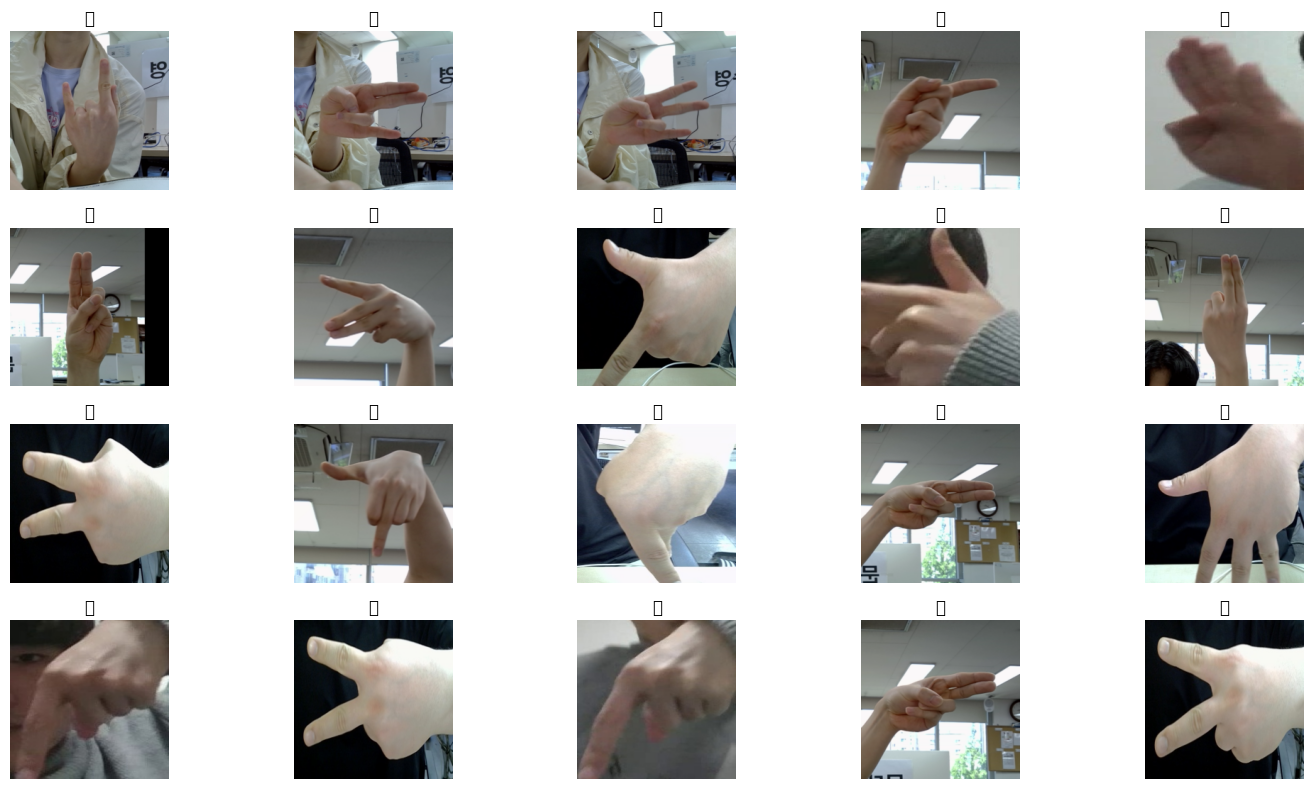

In [8]:
plt.figure(figsize=(15, 8))

sample_count = min(20, len(train_data))
indices = np.random.choice(
    len(train_data),
    sample_count,
    replace=False
)

for plot_index, data_index in enumerate(indices):
    plt.subplot(4, 5, plot_index + 1)
    plt.imshow(train_data[data_index])
    plt.title(class_names[int(train_labels[data_index])])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 8. 학습 데이터 증강

지문자 방향을 보존하기 위해 좌우 반전은 사용하지 않습니다.


In [9]:
img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    brightness_range=(0.75, 1.25),
    zoom_range=0.10,
    fill_mode="nearest"
)

train_gen = img_gen_train.flow(
    train_data,
    train_labels,
    batch_size=32,
    shuffle=True,
    seed=SEED
)


## 9. MobileNetV2 모델 생성

In [10]:
inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="input"
)

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    num_classes,
    activation="softmax",
    name="output"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,951 (9.25 MB)

 Trainable params: 167,967 (656.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. 모델 컴파일

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 11. 학습 전 예측 확인

26/26 ━━━━━━━━━━━━━━━━━━━━ 35s 596ms/step


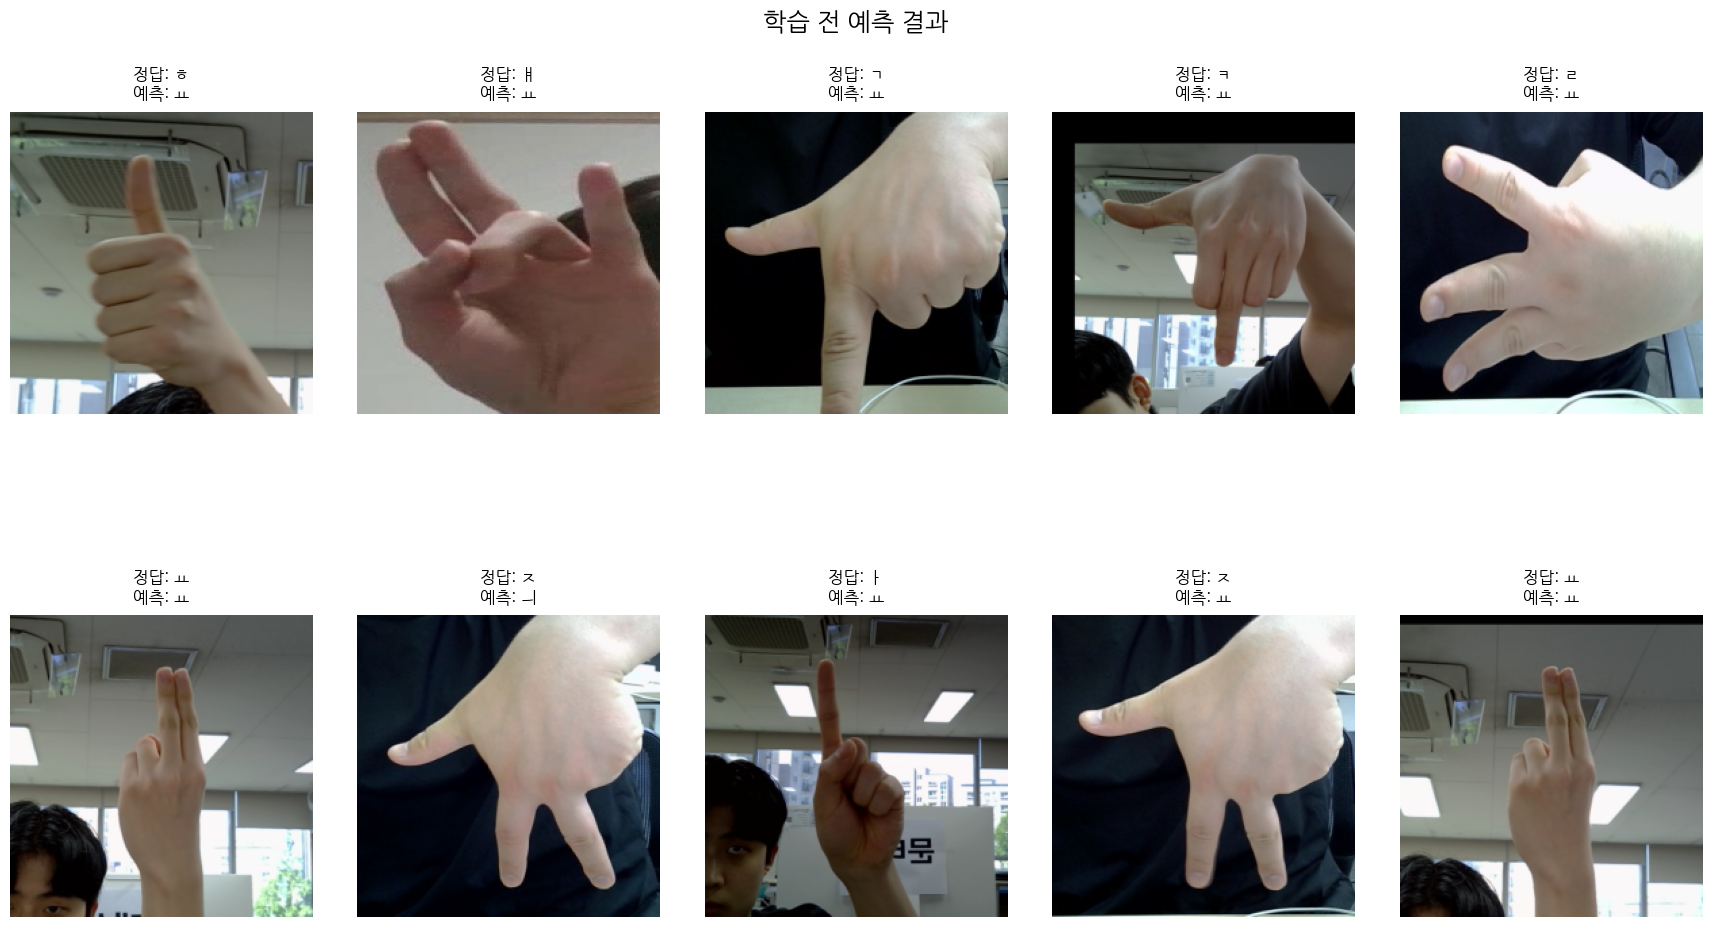

In [12]:
def show_predictions(
    title,
    data,
    labels,
    prediction_indices,
    count=10
):
    count = min(count, len(data))

    selected = np.linspace(
        0,
        len(data) - 1,
        count,
        dtype=int
    )

    rows = 2
    cols = 5

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(18, 10)
    )

    fig.suptitle(
        title,
        fontproperties=korean_font,
        fontsize=18,
        y=0.98
    )

    axes = axes.flatten()

    for plot_index, data_index in enumerate(selected):
        ax = axes[plot_index]

        true_index = int(labels[data_index])
        pred_index = int(prediction_indices[data_index])

        true_name = class_names[true_index]
        pred_name = class_names[pred_index]

        ax.imshow(data[data_index])

        ax.set_title(
            f"정답: {true_name}\n예측: {pred_name}",
            fontproperties=korean_font,
            fontsize=12,
            pad=10
        )

        ax.axis("off")

    for index in range(count, len(axes)):
        axes[index].axis("off")

    plt.subplots_adjust(
        top=0.90,
        bottom=0.05,
        left=0.03,
        right=0.97,
        wspace=0.15,
        hspace=0.45
    )

    plt.show()


before_output = model.predict(
    val_data,
    batch_size=32
)

before_prediction = np.argmax(
    before_output,
    axis=1
)

show_predictions(
    "학습 전 예측 결과",
    val_data,
    val_labels,
    before_prediction
)

## 12. 학습

In [13]:
SAVED_MODEL_NAME = "Korean_Fingerspelling_MobileNetV2.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        SAVED_MODEL_NAME,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    epochs=30,
    callbacks=callbacks,
    validation_data=(val_data, val_labels)
)


Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.0565 - loss: 3.6241
Epoch 1: val_accuracy improved from None to 0.26252, saving model to Korean_Fingerspelling_MobileNetV2.keras

Epoch 1: finished saving model to Korean_Fingerspelling_MobileNetV2.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 84s 815ms/step - accuracy: 0.1033 - loss: 3.3527 - val_accuracy: 0.2625 - val_loss: 2.8922 - learning_rate: 1.0000e-04
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.2389 - loss: 2.8043
Epoch 2: val_accuracy improved from 0.26252 to 0.45543, saving model to Korean_Fingerspelling_MobileNetV2.keras

Epoch 2: finished saving model to Korean_Fingerspelling_MobileNetV2.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 47s 525ms/step - accuracy: 0.2757 - loss: 2.6780 - val_accuracy: 0.4554 - val_loss: 2.2744 - learning_rate: 1.0000e-04
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.3847 - loss: 2.2852
Epoch 3: val_accuracy improved from 0.45543 to 0.61416, saving model to Korean_

## 13. 학습 결과 그래프

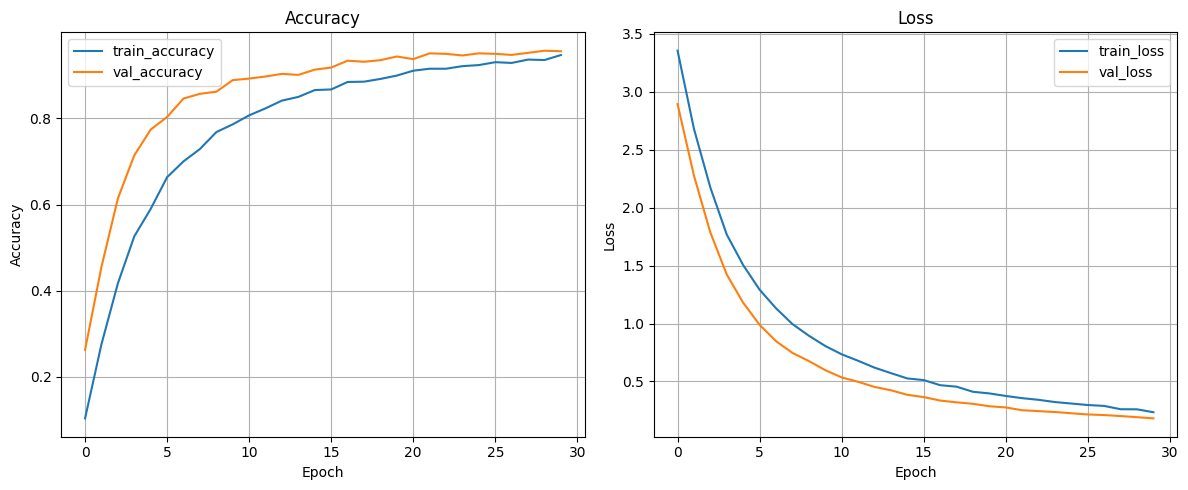

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Accuracy")
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Loss")
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## 14. 최고 성능 모델 불러오기 및 test 평가

In [15]:
model_best = tf.keras.models.load_model(SAVED_MODEL_NAME)

test_loss, test_accuracy = model_best.evaluate(
    test_data,
    test_labels,
    batch_size=32,
    verbose=1
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9471 - loss: 0.2086
Test loss     : 0.2086
Test accuracy : 0.9471


## 15. 최종 예측 샘플 확인

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step


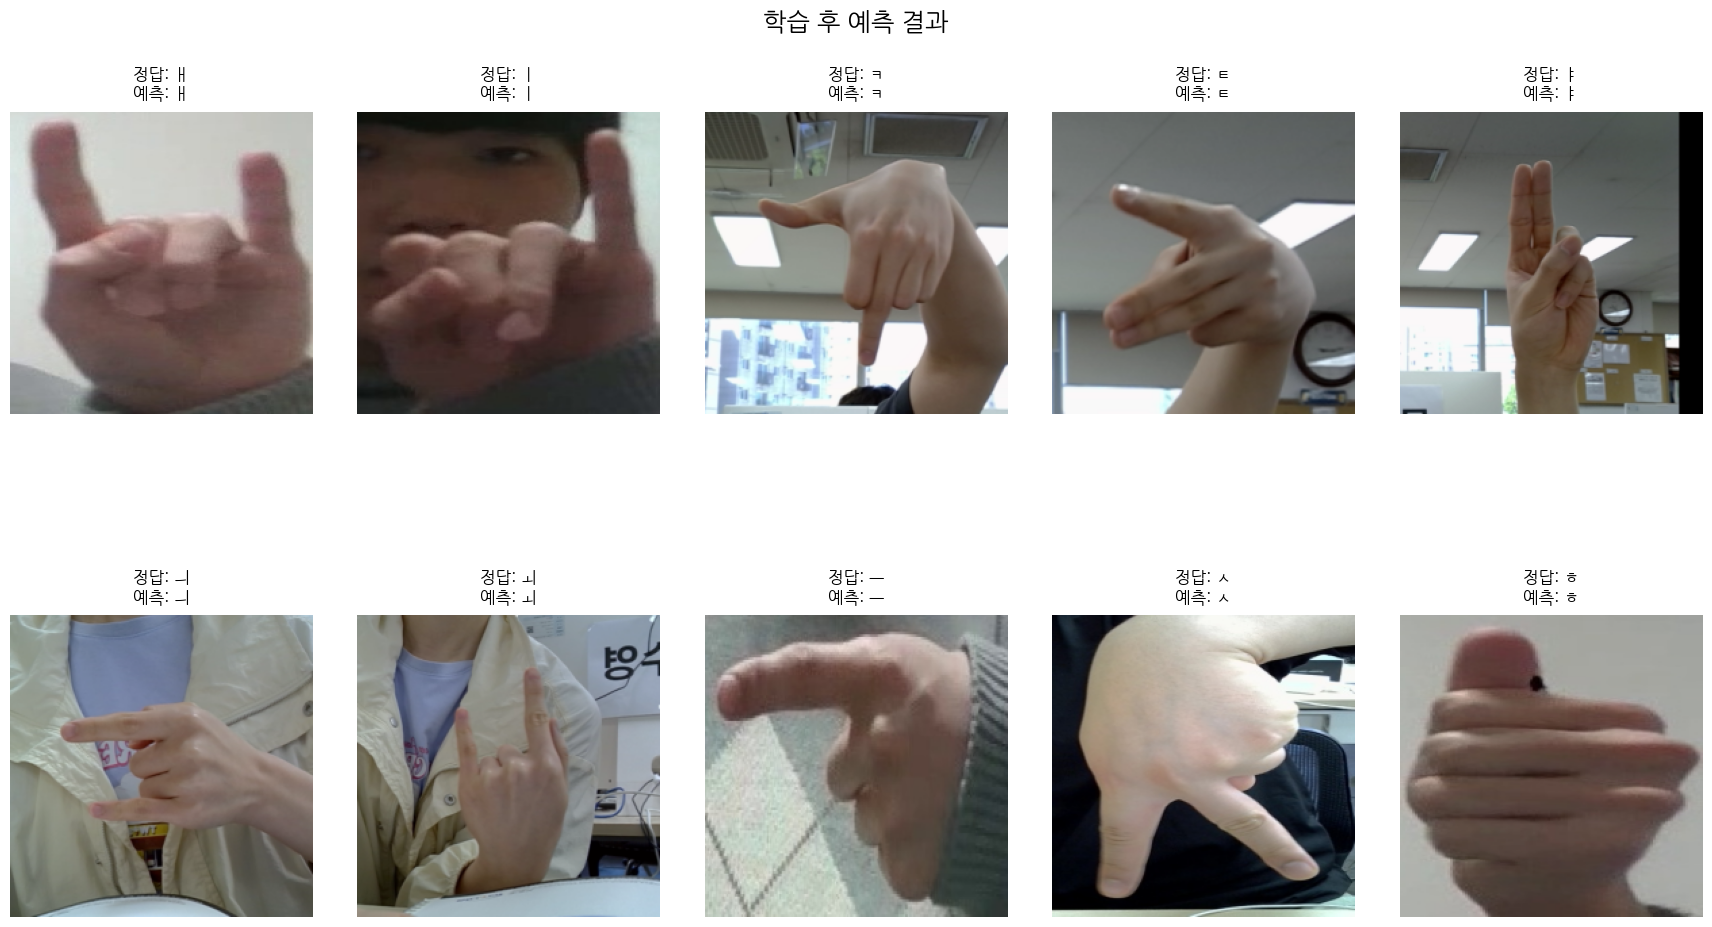

In [16]:
test_output = model_best.predict(
    test_data,
    batch_size=32
)

test_prediction = np.argmax(
    test_output,
    axis=1
)

show_predictions(
    "학습 후 예측 결과",
    test_data,
    test_labels,
    test_prediction,
    count=10
)

## 16. Confusion Matrix 및 클래스별 결과

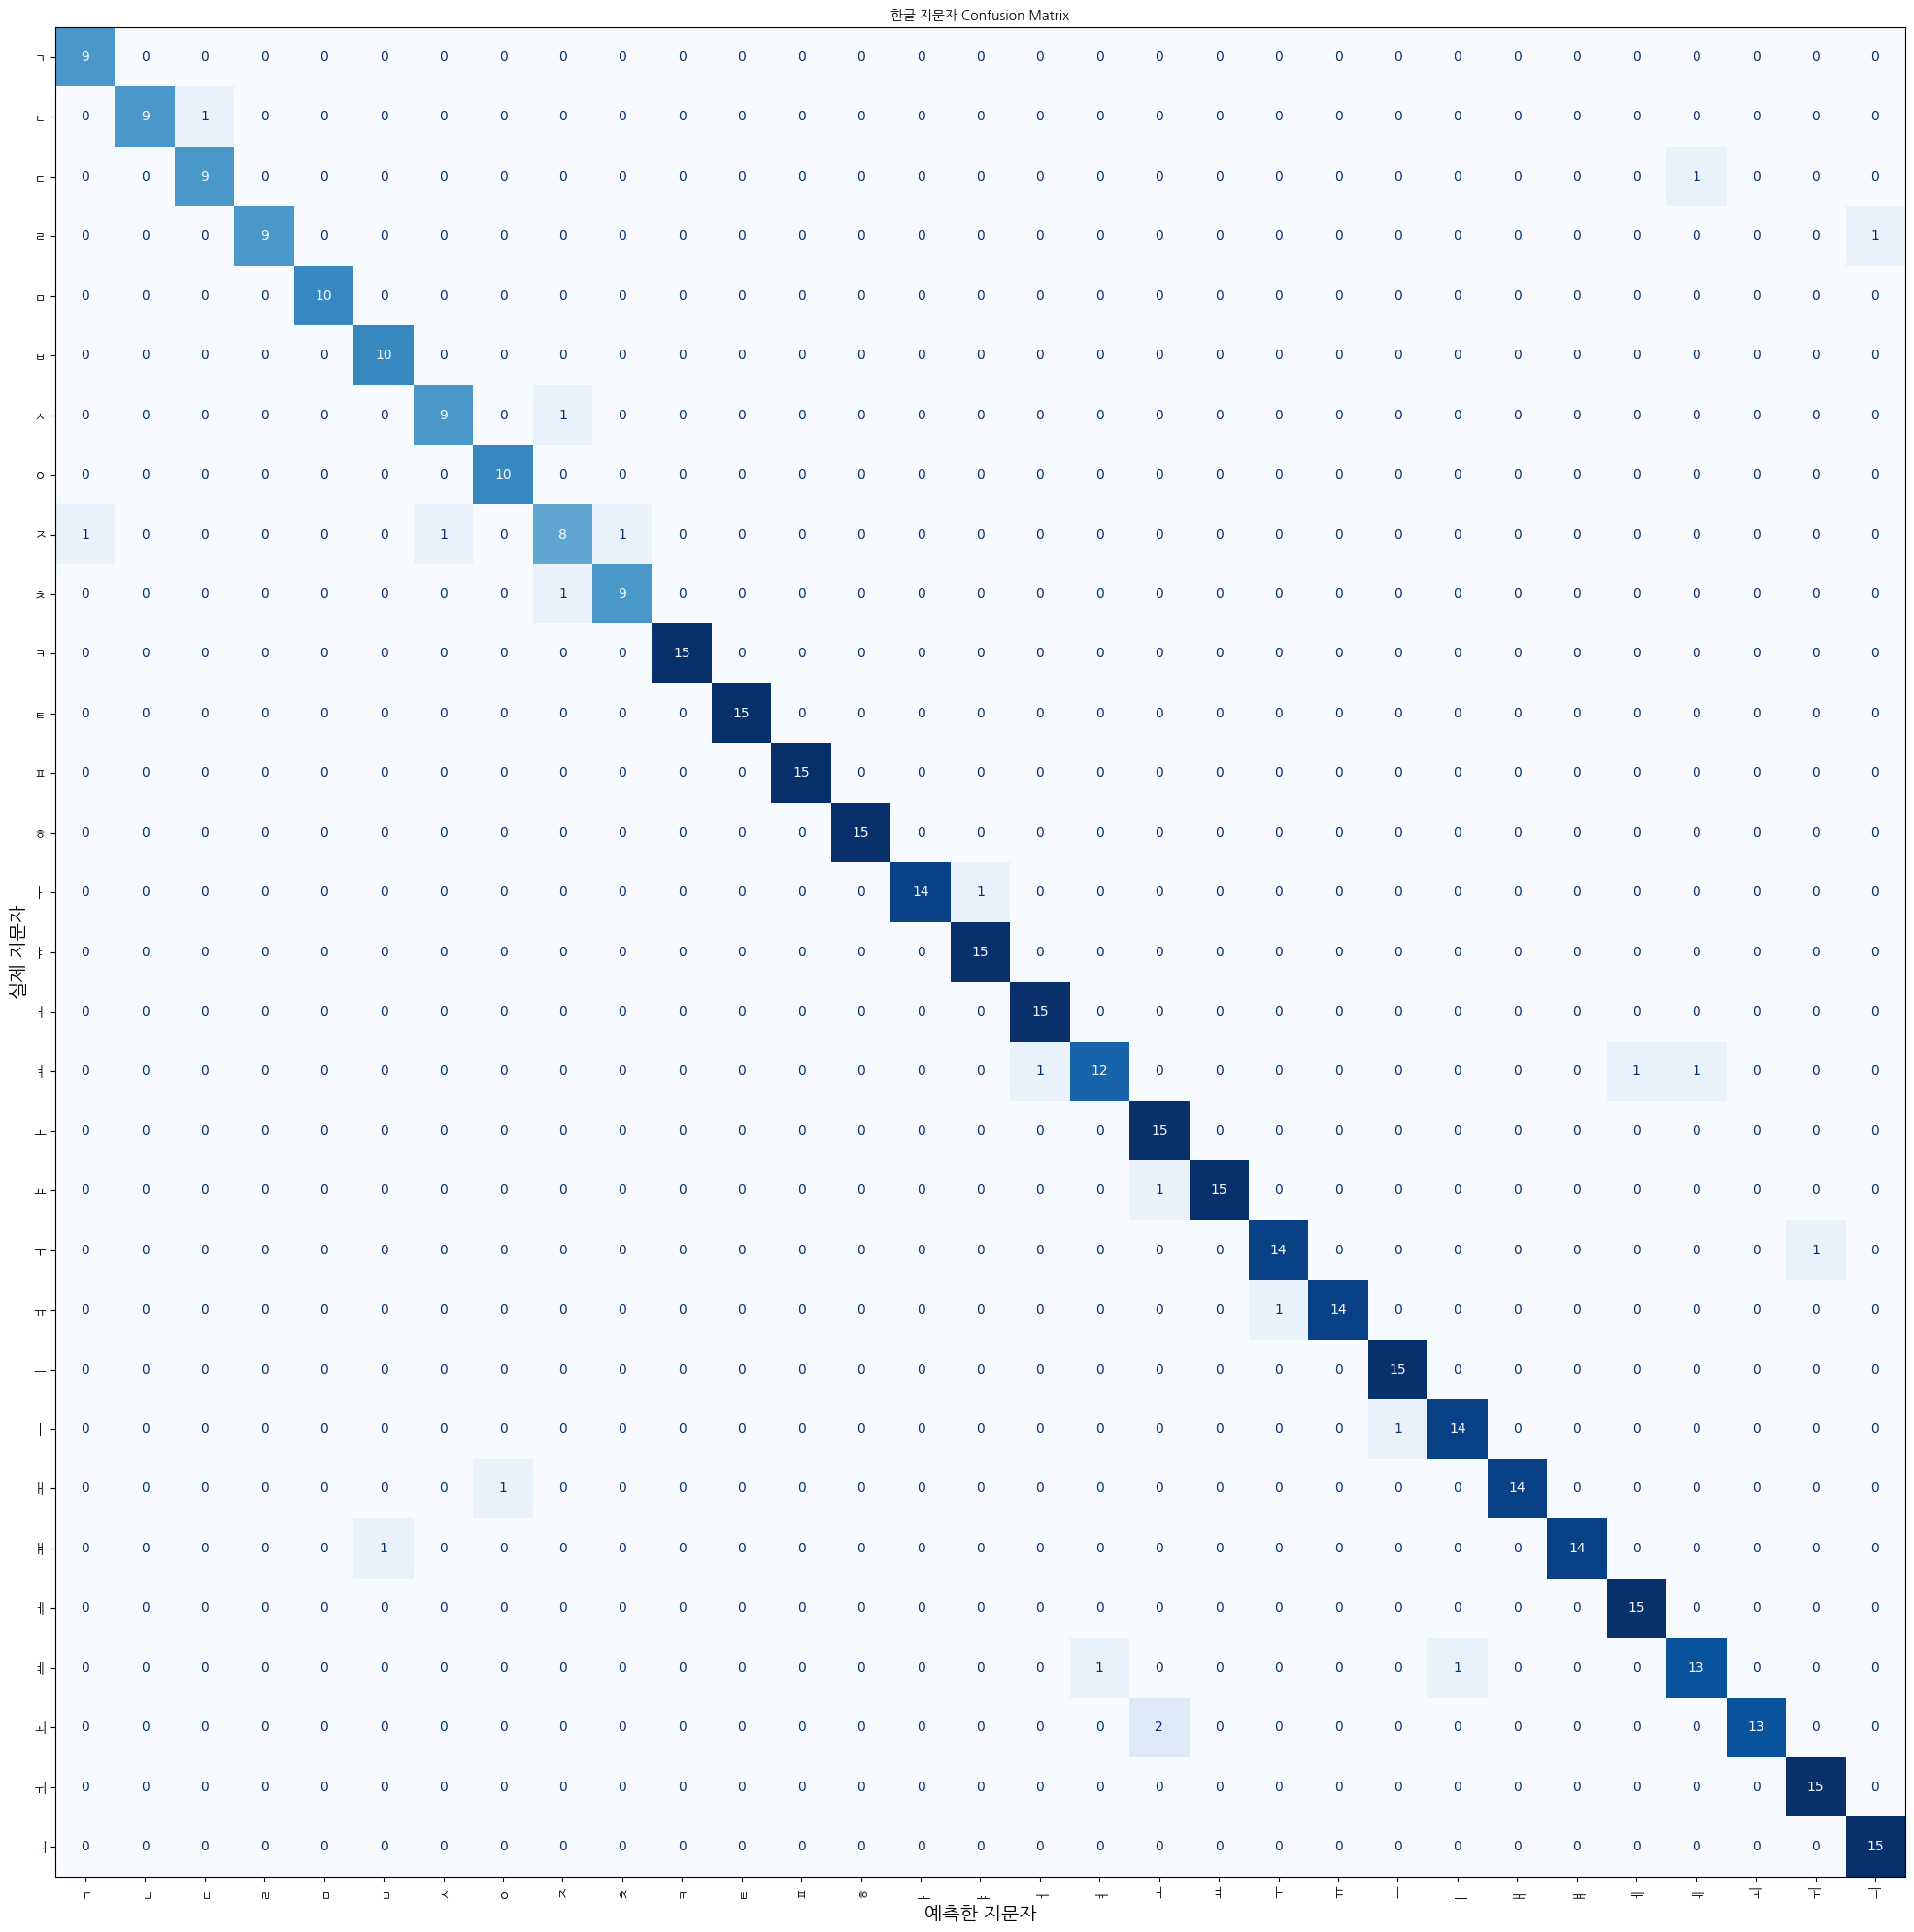

              precision    recall  f1-score   support

           ㄱ     0.9000    1.0000    0.9474         9
           ㄴ     1.0000    0.9000    0.9474        10
           ㄷ     0.9000    0.9000    0.9000        10
           ㄹ     1.0000    0.9000    0.9474        10
           ㅁ     1.0000    1.0000    1.0000        10
           ㅂ     0.9091    1.0000    0.9524        10
           ㅅ     0.9000    0.9000    0.9000        10
           ㅇ     0.9091    1.0000    0.9524        10
           ㅈ     0.8000    0.7273    0.7619        11
           ㅊ     0.9000    0.9000    0.9000        10
           ㅋ     1.0000    1.0000    1.0000        15
           ㅌ     1.0000    1.0000    1.0000        15
           ㅍ     1.0000    1.0000    1.0000        15
           ㅎ     1.0000    1.0000    1.0000        15
           ㅏ     1.0000    0.9333    0.9655        15
           ㅑ     0.9375    1.0000    0.9677        15
           ㅓ     0.9375    1.0000    0.9677        15
           ㅕ     0.9231    

In [17]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

if "test_prediction" not in globals():
    test_output = model_best.predict(
        test_data,
        batch_size=32
    )

    test_prediction = np.argmax(
        test_output,
        axis=1
    )

cm = confusion_matrix(
    test_labels,
    test_prediction,
    labels=np.arange(num_classes)
)

fig, ax = plt.subplots(
    figsize=(20, 20)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

ax.set_title(
    "한글 지문자 Confusion Matrix",
    fontsize=20,
    fontproperties=korean_font
)

ax.set_xlabel(
    "예측한 지문자",
    fontsize=14,
    fontproperties=korean_font
)

ax.set_ylabel(
    "실제 지문자",
    fontsize=14,
    fontproperties=korean_font
)

for label in ax.get_xticklabels():
    label.set_fontproperties(korean_font)
    label.set_fontsize(10)

for label in ax.get_yticklabels():
    label.set_fontproperties(korean_font)
    label.set_fontsize(10)

plt.tight_layout()
plt.show()

print(
    classification_report(
        test_labels,
        test_prediction,
        labels=np.arange(num_classes),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


## 17. ONNX 변환

Jetson에서는 이 ONNX 파일을 이용해 TensorRT `.engine` 파일을 생성합니다.


In [18]:
!pip -q install tf2onnx onnx onnxsim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 58.7 MB/s eta 0:00:00


In [19]:
import tf2onnx

ONNX_MODEL_NAME = "Korean_Fingerspelling_MobileNetV2.onnx"

spec = (
    tf.TensorSpec(
        (1, IMG_SIZE, IMG_SIZE, 3),
        tf.float32,
        name="input"
    ),
)

model_proto, _ = tf2onnx.convert.from_keras(
    model_best,
    input_signature=spec,
    opset=18,
    output_path=ONNX_MODEL_NAME
)

print("ONNX 변환 완료:", ONNX_MODEL_NAME)


ONNX 변환 완료: Korean_Fingerspelling_MobileNetV2.onnx


## 18. ONNX 단순화

In [20]:
ONNXSIM_MODEL_NAME = "Korean_Fingerspelling_MobileNetV2.sim.onnx"

!onnxsim "$ONNX_MODEL_NAME" "$ONNXSIM_MODEL_NAME"


Installing onnxruntime by `/usr/bin/python3 -m pip install onnxruntime`, please 
wait for a moment..
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 45.0 MB/s eta 0:00:00
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 27             │ 27               │
│ Clip       │ 35             │ 35               │
│ Constant   │ 131            │ 130              │
│ Conv       │ 52             │ 52               │
│ Gemm       │ 2              │ 2                │
│ Mul        │ 18             │ 18               │
│ Pad        │ 4              │ 0                │
│ ReduceMean │ 1              │ 1                │
│ Relu       │ 1              │ 1                │
│ Softmax    │ 1              │ 1                │
│ Sub        │ 1              │ 1                │
│ Transpose  │ 2              │ 2                │
│ Model 

## 19. 결과 파일 묶기 및 다운로드

In [21]:
TARBALL_NAME = "Korean_Fingerspelling_MobileNetV2_Result.tar.gz"

!tar -zcvf "$TARBALL_NAME"     "$SAVED_MODEL_NAME"     "$ONNX_MODEL_NAME"     "$ONNXSIM_MODEL_NAME"     "$CLASS_NAMES_FILE"

print("생성 완료:", TARBALL_NAME)


Korean_Fingerspelling_MobileNetV2.keras
Korean_Fingerspelling_MobileNetV2.onnx
Korean_Fingerspelling_MobileNetV2.sim.onnx
korean_fingerspelling_class_names.json
생성 완료: Korean_Fingerspelling_MobileNetV2_Result.tar.gz


In [22]:
try:
    from google.colab import files
    files.download(TARBALL_NAME)
except Exception as e:
    print("자동 다운로드는 Colab에서만 지원됩니다.")
    print(e)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>